# Exercise 03 — Containers, Lists, Dicts (Training Assignment)

NUMA01 VT2026 — Arvid Brenner & Sixten Midsem

Lösningar till `exercise03_summer.md`. Repeterar list comprehensions, slicing,
dictionaries, sets och bisektionsmetoden.


## Task 1 — Listoperationer

Vi spårar `L` steg för steg. Notera att `L[2:2] = [-3]` *infogar* `-3` på
plats 2, medan `L[3:4] = []` *raderar* element 3, och `L[2:5] = [-5]` *ersätter*
en tre element lång slice med ett enda element.


In [1]:
L = [0, 1, 2, 1, 0, -1, -2, -1, 0]

print("L[0]    =", L[0])           # 0
print("L[-1]   =", L[-1])          # 0
print("L[:-1]  =", L[:-1])         # alla utom sista

print("L+L[1:-1]+L =", L + L[1:-1] + L)

L[2:2] = [-3]                      # infoga -3 på plats 2
print("efter L[2:2] = [-3]:", L)

L[3:4] = []                        # ta bort element 3
print("efter L[3:4] = []: ", L)

L[2:5] = [-5]                      # ersätt slice [2:5] med [-5]
print("efter L[2:5] = [-5]:", L)


L[0]    = 0
L[-1]   = 0
L[:-1]  = [0, 1, 2, 1, 0, -1, -2, -1]
L+L[1:-1]+L = [0, 1, 2, 1, 0, -1, -2, -1, 0, 1, 2, 1, 0, -1, -2, -1, 0, 1, 2, 1, 0, -1, -2, -1, 0]
efter L[2:2] = [-3]: [0, 1, -3, 2, 1, 0, -1, -2, -1, 0]
efter L[3:4] = []:  [0, 1, -3, 1, 0, -1, -2, -1, 0]
efter L[2:5] = [-5]: [0, 1, -5, -1, -2, -1, 0]


## Task 2 — Dictionaries

- `print(d['nokey'])` ger **KeyError** — nyckeln saknas.
- `del d['key']` följt av `print(d['key'])` ger **KeyError** av samma skäl.
- `d[(1, 2)] = 'tuple'` är **OK** — tupler är hashbara.
- `d[[1, 2]] = 'list'` ger **TypeError: unhashable type: 'list'** — listor är
  muterbara och kan inte användas som nycklar.


In [2]:
d = dict()

# print(d['nokey'])    # KeyError

d['key'] = 3
print(d['key'])

del d['key']
# print(d['key'])      # KeyError

d[(1, 2)] = 'tuple'    # OK
print(d)

try:
    d[[1, 2]] = 'list' # TypeError
except TypeError as e:
    print("TypeError:", e)


3
{(1, 2): 'tuple'}
TypeError: cannot use 'list' as a dict key (unhashable type: 'list')


## Task 3

Övning utan beskrivning i PDF:en — troligen muntlig under övningen. Hoppas
över här.


## Task 4 — Avståndstabell, slicing

Bygger `distance` som en lista av listor och plockar ut den nedre triangeln
(utan diagonalen) som `reddistance`. Två varianter:

1. for-loop
2. ren list comprehension med slicing


In [3]:
distance = [
    [ 0, 20, 30, 40],
    [20,  0, 50, 60],
    [30, 50,  0, 70],
    [40, 60, 70,  0],
]

# Variant 1: for-loop
reddistance_loop = []
for i, row in enumerate(distance):
    if i > 0:
        reddistance_loop.append(row[:i])

print("for-loop:")
for row in reddistance_loop:
    print(row)


for-loop:
[20]
[30, 50]
[40, 60, 70]


In [4]:
# Variant 2: enbart list comprehension + slicing
reddistance_lc = [row[:i] for i, row in enumerate(distance) if i > 0]

print("list comprehension:")
for row in reddistance_lc:
    print(row)

assert reddistance_loop == reddistance_lc


list comprehension:
[20]
[30, 50]
[40, 60, 70]


## Task 5 — Symmetrisk differens av mängder

$(A \setminus B) \cup (B \setminus A)$ — element som ligger i exakt en av
mängderna.


In [5]:
def sym_diff(A, B):
    """Returnera (A \\ B) ∪ (B \\ A)."""
    return (A - B) | (B - A)


A = {1, 2, 3, 4}
B = {3, 4, 5, 6}

print("egen sym_diff      :", sym_diff(A, B))
print("A.symmetric_difference(B):", A.symmetric_difference(B))

assert sym_diff(A, B) == A.symmetric_difference(B)


egen sym_diff      : {1, 2, 5, 6}
A.symmetric_difference(B): {1, 2, 5, 6}


## Task 6 — `intersection` vs `intersection_update`

- `A.intersection(B)` returnerar en **ny** mängd; `A` förblir oförändrad.
- `A.intersection_update(B)` muterar `A` på plats: `A` blir snittet och
  metoden returnerar `None`.

Samma mönster gäller `union`/`update`, `difference`/`difference_update`,
`symmetric_difference`/`symmetric_difference_update`.


In [6]:
A = {1, 2, 3, 4}
B = {3, 4, 5, 6}

C = A.intersection(B)
print("A efter intersection      :", A, "  C =", C)

A.intersection_update(B)
print("A efter intersection_update:", A)


A efter intersection      : {1, 2, 3, 4}   C = {3, 4}
A efter intersection_update: {3, 4}


## Task 7 — Tomma mängden är delmängd av varje mängd

I Python: `set().issubset(X)` är alltid `True` och `set() <= X` likaså.


In [7]:
empty = set()
for X in [{1, 2, 3}, set(), {'a'}, {1, 2, 3, 4, 5}]:
    print(f"{empty} <= {X}?  {empty <= X}")


set() <= {1, 2, 3}?  True
set() <= set()?  True
set() <= {'a'}?  True
set() <= {1, 2, 3, 4, 5}?  True


## Task 8 — Bisektionsmetoden

Hittar ett nollställe i $[a, b]$ förutsatt att $f(a)\,f(b) < 0$. Vi kollar
teckenbytet i den vänstra halvan och uppdaterar antingen `b` eller `a`.

**Stoppvillkor:** $b - a < \text{tol}$.


In [8]:
from numpy import arctan


def bisect(f, a, b, tol=1e-8, max_iter=200):
    """Hitta nollställe till f i [a, b] med bisektionsmetoden.

    Kräver f(a)*f(b) < 0. Returnerar (mittpunkt, antal iterationer).
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) och f(b) måste ha olika tecken")

    n = 0
    while b - a > tol and n < max_iter:
        m = (a + b) / 2
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
        n += 1
    return (a + b) / 2, n


# arctan har ett nollställe i 0
root, n = bisect(arctan, -1.0, 2.0)
print(f"arctan: rot ≈ {root:.10f}  ({n} iter)")

# 3x^2 - 5 har nollställen ±sqrt(5/3) ≈ ±1.290994
def f(x):
    return 3 * x ** 2 - 5

# Intervallet [-0.5, 0.6] innehåller ingen nollställe — f har samma tecken där
import numpy as np
print("\nf(-0.5) =", f(-0.5), ",  f(0.6) =", f(0.6),
      "→ samma tecken, ingen rot kan garanteras")
try:
    bisect(f, -0.5, 0.6)
except ValueError as e:
    print("ValueError:", e)

# Intervallet [-1.5, -0.4] innehåller -sqrt(5/3) ≈ -1.291
root2, n2 = bisect(f, -1.5, -0.4)
print(f"\n3x^2-5 på [-1.5,-0.4]: rot ≈ {root2:.10f}  (sant: {-np.sqrt(5/3):.10f}, {n2} iter)")


arctan: rot ≈ -0.0000000009  (29 iter)

f(-0.5) = -4.25 ,  f(0.6) = -3.92 → samma tecken, ingen rot kan garanteras
ValueError: f(a) och f(b) måste ha olika tecken

3x^2-5 på [-1.5,-0.4]: rot ≈ -1.2909944501  (sant: -1.2909944487, 27 iter)


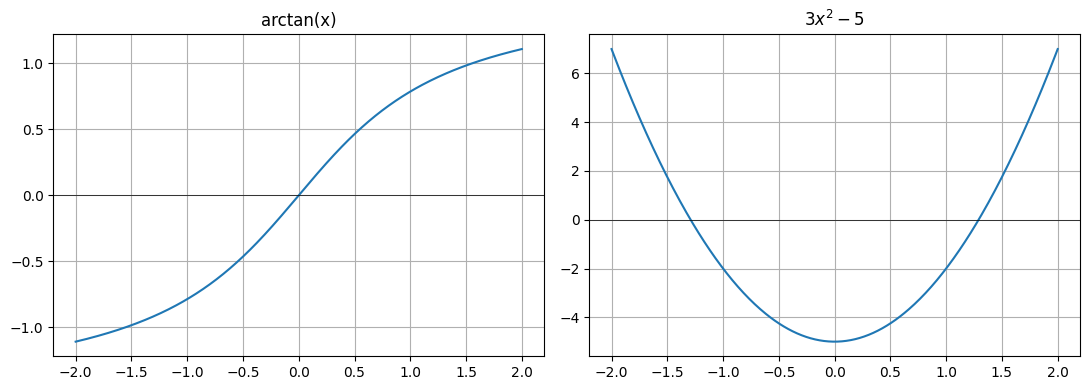

In [9]:
# Plot för att illustrera
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-2, 2, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs, np.arctan(xs)); axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('arctan(x)'); axes[0].grid(True)

axes[1].plot(xs, 3*xs**2 - 5); axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(r'$3x^2 - 5$'); axes[1].grid(True)
plt.tight_layout(); plt.show()
